# 🌱 Plant Disease Detection Using Deep Learning

## Project Overview

This project develops a Deep Learning model to classify plant leaf images
into different disease categories using the PlantVillage dataset.

### Objectives
- Explore and analyze the PlantVillage image dataset
- Preprocess and augment plant leaf images
- Build a Convolutional Neural Network (CNN)
- Train and evaluate the CNN model
- Apply Transfer Learning to improve performance
- Compare the CNN and Transfer Learning models
- Predict the disease of a new plant leaf image

### Technologies
- Python
- TensorFlow / Keras
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Google Colab
- NVIDIA T4 GPU

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU detected.")

GPU detected:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
!pip -q install kagglehub

import kagglehub

path = kagglehub.dataset_download("emmarex/plantdisease")

print("Dataset downloaded to:", path)

In [ ]:
dataset_path = "/kaggle/input/plantdisease/PlantVillage"

print("Dataset path:", dataset_path)
print("Dataset exists:", os.path.exists(dataset_path))

Dataset path: /kaggle/input/plantdisease/PlantVillage
Dataset exists: True


In [ ]:
class_counts = {}

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        image_count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        class_counts[class_name] = image_count

class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

print("Number of classes:", len(class_df))
print("Total number of images:", class_df["Number of Images"].sum())

display(class_df)

Number of classes: 15
Total number of images: 20638


,Class,Number of Images
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___Late_blight,1000
4,Potato___healthy,152
5,Tomato_Bacterial_spot,2127
6,Tomato_Early_blight,1000
7,Tomato_Late_blight,1909
8,Tomato_Leaf_Mold,952
9,Tomato_Septoria_leaf_spot,1771


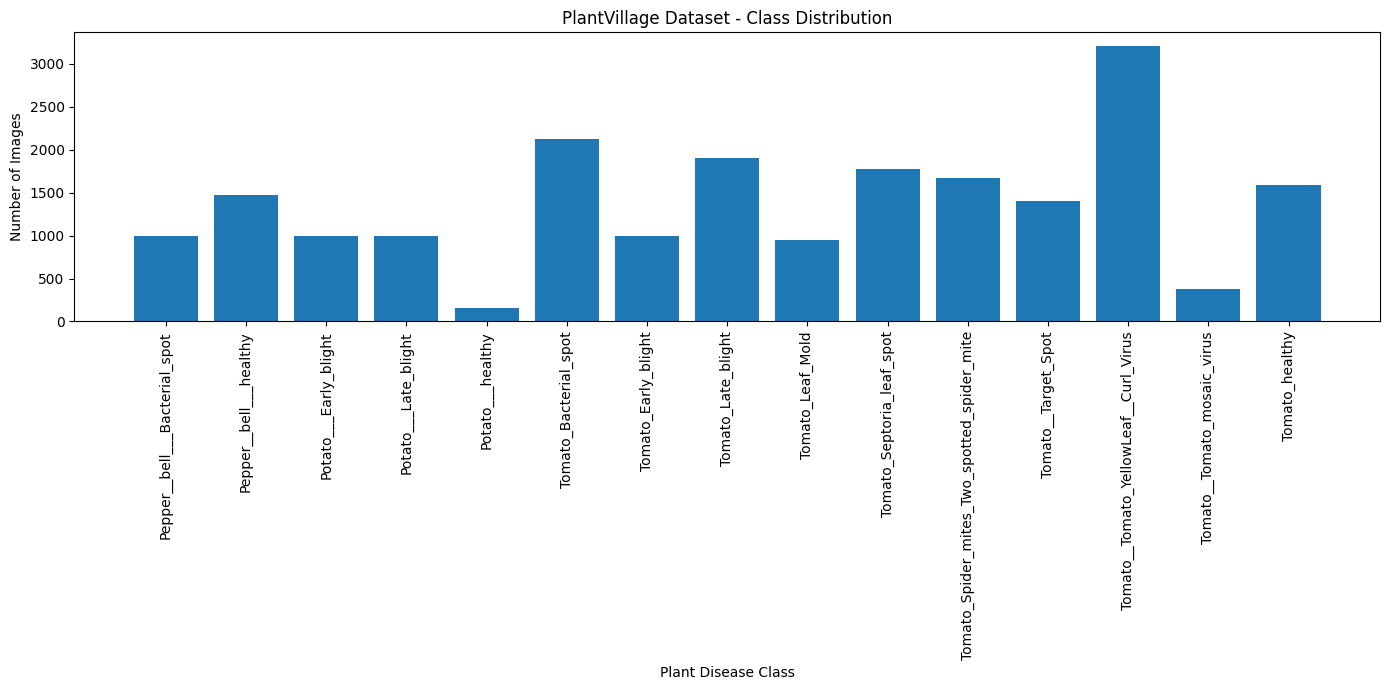

In [ ]:
plt.figure(figsize=(14, 7))

plt.bar(
    class_df["Class"],
    class_df["Number of Images"]
)

plt.xlabel("Plant Disease Class")
plt.ylabel("Number of Images")
plt.title("PlantVillage Dataset - Class Distribution")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

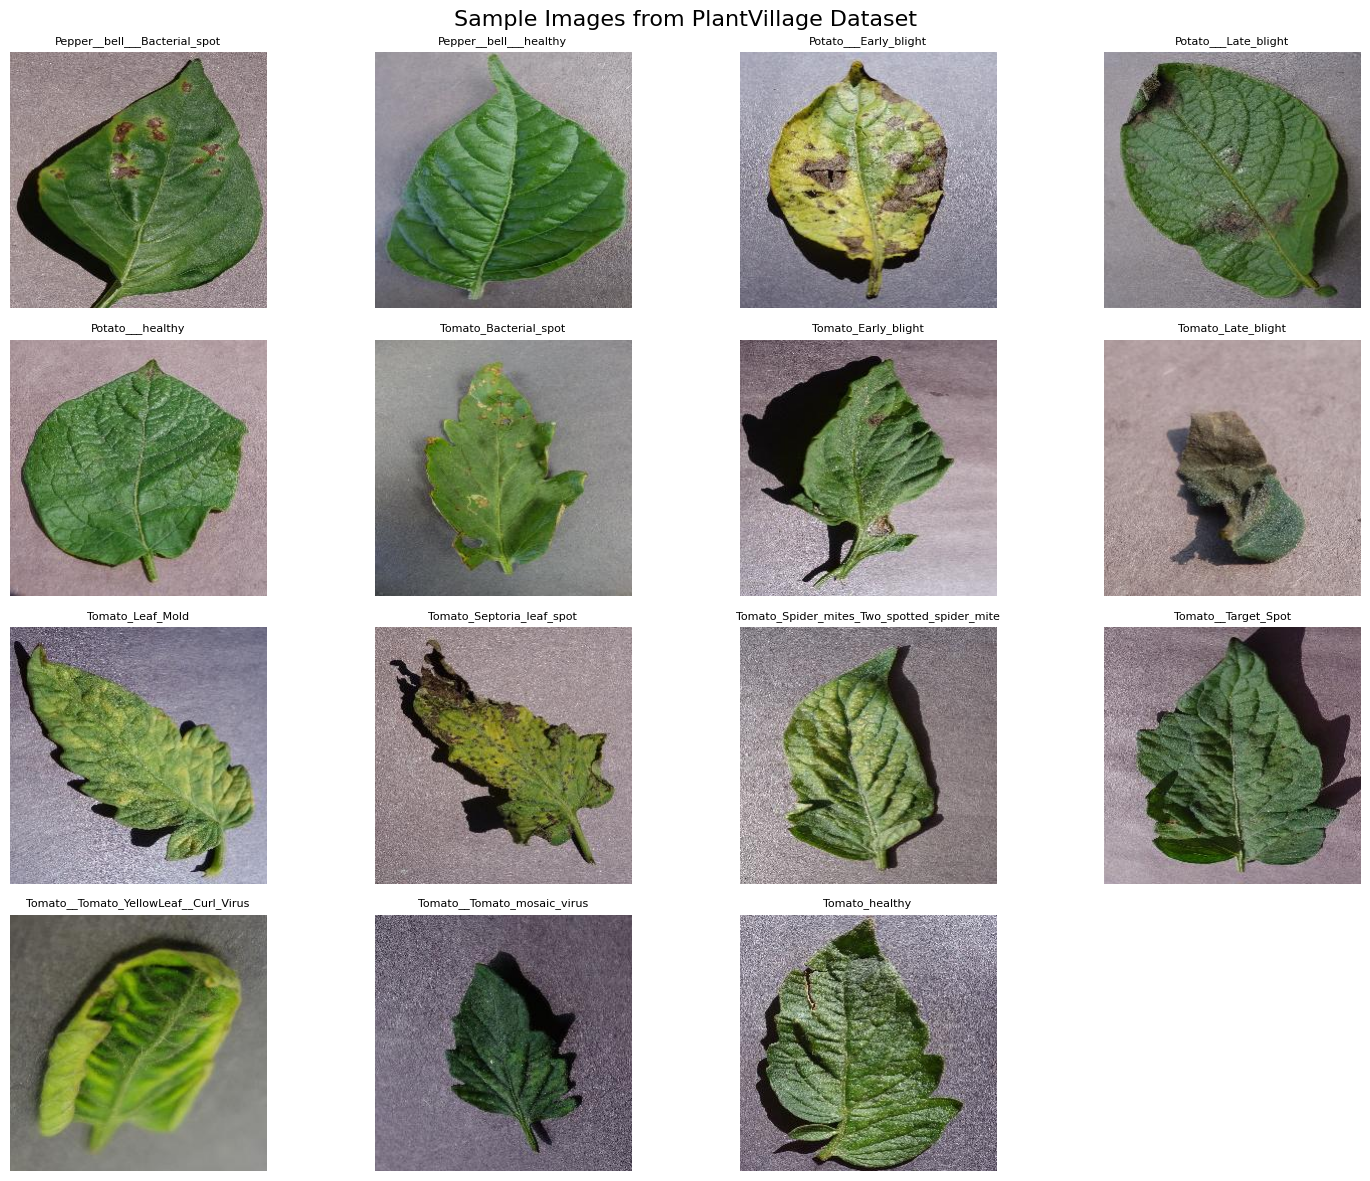

In [ ]:
plt.figure(figsize=(15, 12))

sample_classes = class_df["Class"].tolist()

for i, class_name in enumerate(sample_classes):
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_name = random.choice(image_files)
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(4, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.suptitle("Sample Images from PlantVillage Dataset", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:", class_names)

Found 20638 files belonging to 15 classes.
Using 14447 files for training.
Found 20638 files belonging to 15 classes.
Using 6191 files for validation.
Number of classes: 15
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()

val_batches = temp_batches // 2

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Training batches: 452
Validation batches: 97
Test batches: 97


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

normalization = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(
    lambda x, y: (normalization(data_augmentation(x, training=True)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("Preprocessing and augmentation completed.")

Preprocessing and augmentation completed.


In [ ]:
cnn_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
], name="Plant_Disease_CNN")

print("CNN model created successfully.")

CNN model created successfully.


In [ ]:
cnn_model.summary()

Model: "Plant_Disease_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,829,711 (37.50 MB)

 Trainable params: 9,829,711 (37.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 183s 381ms/step - accuracy: 0.4184 - loss: 1.7975 - val_accuracy: 0.6157 - val_loss: 1.1194
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 154s 339ms/step - accuracy: 0.6498 - loss: 1.0719 - val_accuracy: 0.7139 - val_loss: 0.8270
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 202s 340ms/step - accuracy: 0.7243 - loss: 0.8278 - val_accuracy: 0.7555 - val_loss: 0.6679
Epoch 4/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 200s 336ms/step - accuracy: 0.7554 - loss: 0.7253 - val_accuracy: 0.8402 - val_loss: 0.4783
Epoch 5/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 150s 332ms/step - accuracy: 0.8007 - loss: 0.5974 - val_accuracy: 0.8582 - val_loss: 0.4086
Epoch 6/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 203s 334ms/step - accuracy: 0.8283 - loss: 0.5051 - val_accuracy: 0.8628 - val_loss: 0.4045
Epoch 7/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 151s 333ms/step - accuracy: 0.8547 - loss: 0.4315 - val_accuracy: 0.9062 - val_loss: 0.2715
Epoch 8/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 204s 338ms/step - accuracy: 0.8681 -

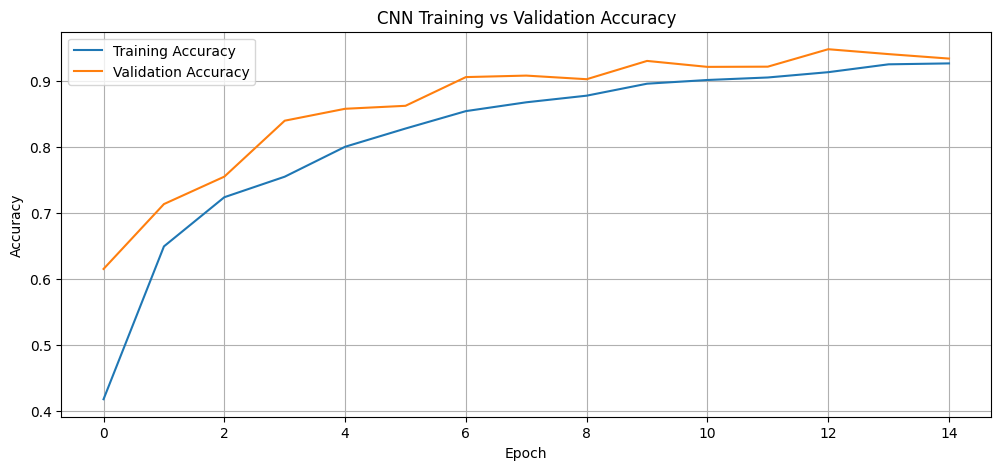

In [ ]:
history_df = pd.DataFrame(history_cnn.history)

plt.figure(figsize=(12, 5))

plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

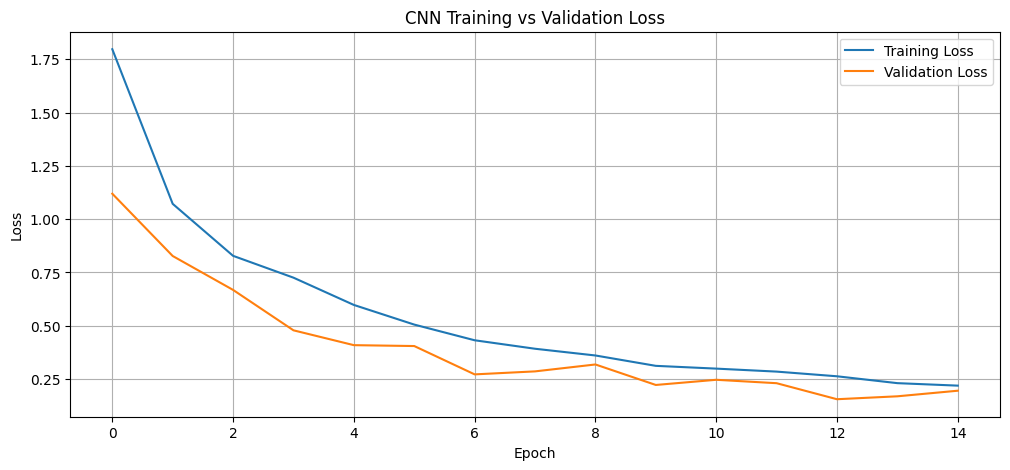

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.9436 - loss: 0.1559
Test Loss: 0.1559
Test Accuracy: 0.9436
Test Accuracy: 94.36%


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")
print("Number of test samples:", len(y_true))

Predictions generated successfully.
Number of test samples: 3087


In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("CNN Classification Report\n")
print(report)

CNN Classification Report

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9653    0.9521    0.9586       146
                     Pepper__bell___healthy     0.9864    0.9775    0.9819       222
                      Potato___Early_blight     0.9724    0.9860    0.9792       143
                       Potato___Late_blight     0.8690    0.9403    0.9032       134
                           Potato___healthy     0.8000    0.8000    0.8000        25
                      Tomato_Bacterial_spot     0.9966    0.8832    0.9365       334
                        Tomato_Early_blight     0.8511    0.8000    0.8247       150
                         Tomato_Late_blight     0.9113    0.9468    0.9287       282
                           Tomato_Leaf_Mold     0.9924    0.9420    0.9665       138
                  Tomato_Septoria_leaf_spot     0.9504    0.9404    0.9453       285
Tomato_Spider_mites_Two_spotted_spide

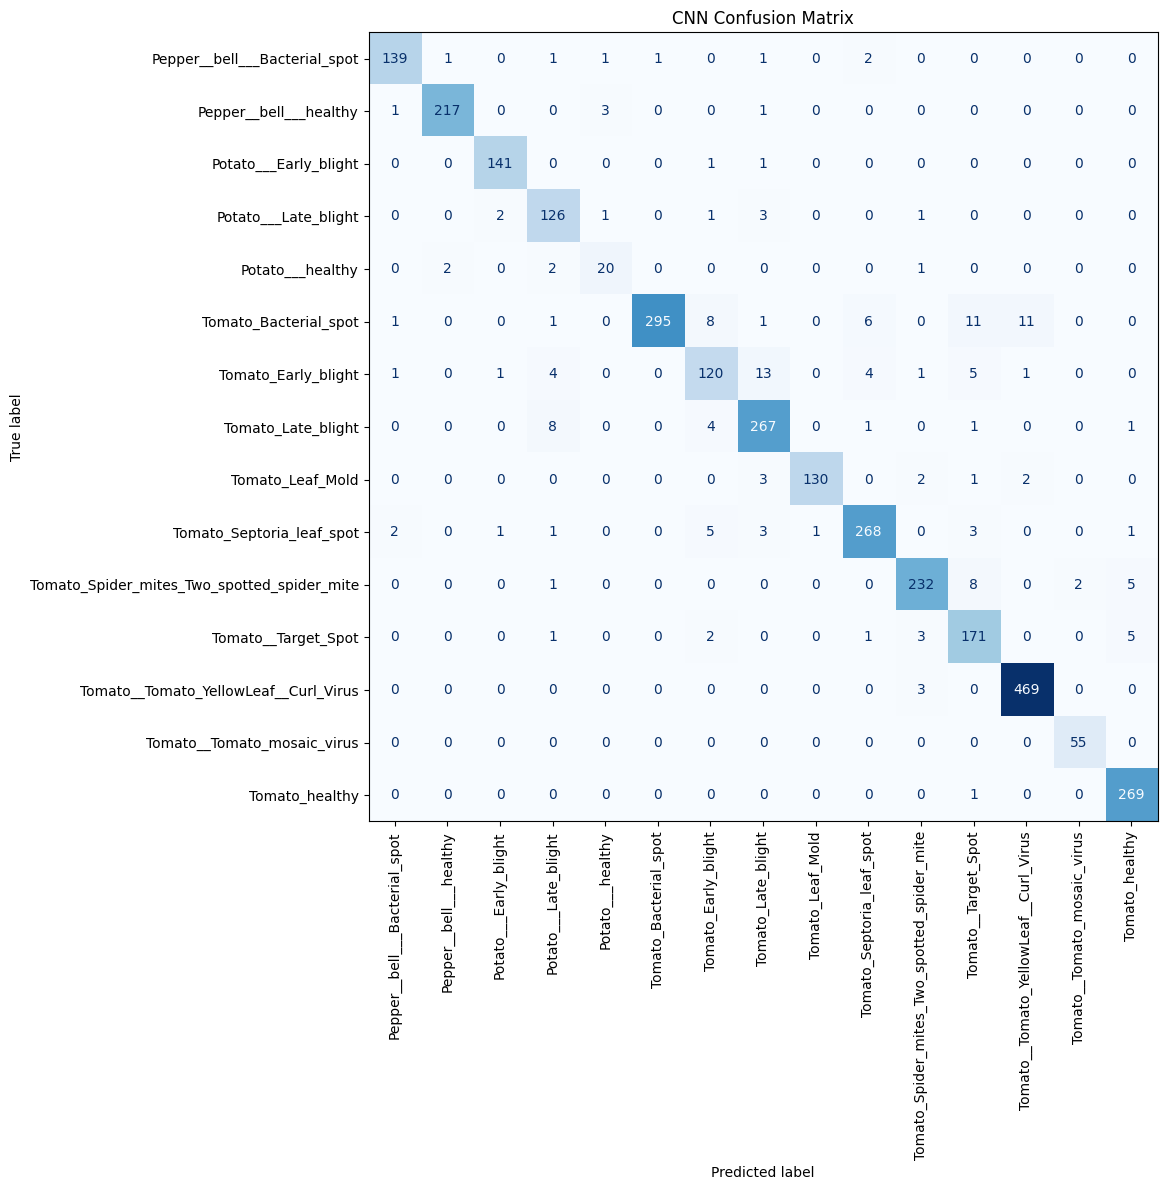

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=plt.gca(),
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving leaf.jpg to leaf.jpg


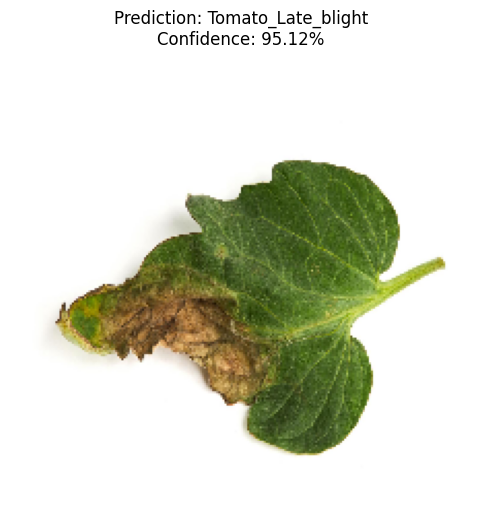

Predicted class: Tomato_Late_blight
Confidence: 95.12%


In [ ]:
uploaded_file = list(uploaded.keys())[0]

image = tf.keras.utils.load_img(
    uploaded_file,
    target_size=(224, 224)
)

image_array = tf.keras.utils.img_to_array(image)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = cnn_model.predict(image_array, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

# Conclusion

In this project, a Convolutional Neural Network (CNN) was developed to
classify plant leaf images into different disease categories using the
PlantVillage dataset.

The project included:

- Exploratory Data Analysis of the image dataset
- Analysis of the distribution of disease classes
- Image preprocessing and normalization
- Data augmentation to improve model generalization
- A CNN architecture for plant disease classification
- Training and validation of the CNN model
- Evaluation using test accuracy
- Classification report with precision, recall, and F1-score
- Confusion matrix analysis
- Prediction of disease classes for new leaf images

The results demonstrate how Deep Learning and CNNs can be applied to
image-based plant disease classification.

## Future Scope

The project can be further improved by:

- Using a larger and more diverse dataset
- Applying advanced CNN architectures
- Using transfer learning
- Collecting real-world field images
- Deploying the trained model as a web or mobile application